# Mô-đun 2: Peer Group Benchmarking bằng K-Nearest Neighbors

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Module:** K-NN Peer Group Benchmarking  
**Mục tiêu:** Giải thích và đối chiếu kết quả dự đoán mức lương bằng cách tìm các hồ sơ tương đồng nhất trong dữ liệu lịch sử

---

## Tổng quan phương pháp

Thay vì chỉ đưa ra một con số dự đoán từ mô hình "hộp đen", module này cung cấp **bằng chứng thực nghiệm** từ dữ liệu thực tế:

> *Những người có hồ sơ gần giống bạn nhất đang nhận mức lương bao nhiêu?*

### Khoảng cách Euclidean (sau chuẩn hóa)

$$d(x_0, x_i) = \sqrt{\sum_{j=1}^{p} (x_{0j} - x_{ij})^2}$$

Dữ liệu đã qua `StandardScaler` trong preprocessing pipeline — nên các biến đều có scale tương đương, Euclidean distance là hợp lý.

### Distance-Weighted K-NN

$$w_i = \frac{1}{d_i^2 + \varepsilon}, \quad \varepsilon = 10^{-10}$$

Người láng giềng gần hơn có ảnh hưởng lớn hơn — phản ánh đúng logic "hồ sơ tương đồng hơn → đáng tin cậy hơn".

---

## Các bước chính

1. Load dữ liệu và mô hình đã huấn luyện  
2. Xây dựng K-NN với StandardScaler độc lập  
3. Tự động lựa chọn k* tối ưu (k ∈ {3,5,7,9,11,13,15,17,19})  
4. Peer Group Benchmark cho từng hồ sơ đầu vào  
5. Trực quan hóa kết quả  
6. Xuất DataFrame kết quả

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import scipy.sparse as sp
import warnings
import os
import re
from typing import Optional, List, Dict, Tuple

from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Thư mục ────────────────────────────────────────────────────────────────────
FIGURE_DIR = 'figure/KNN'
DATA_DIR   = 'preprocessing_salary_outputs'
os.makedirs(FIGURE_DIR, exist_ok=True)

EPSILON = 1e-10   # tránh chia cho 0 trong distance weighting

print("✅ Thư viện đã sẵn sàng.")
print(f"   Figure dir : {FIGURE_DIR}")
print(f"   Data dir   : {DATA_DIR}")

✅ Thư viện đã sẵn sàng.
   Figure dir : figure/KNN
   Data dir   : preprocessing_salary_outputs


## 2. Load dữ liệu đã tiền xử lý

Tái sử dụng **cùng pipeline** với RF / LightGBM / XGBoost:
- `X_train_processed.npz` — ma trận đặc trưng (sparse, 48 features sau One-Hot + Scaling)
- `y_train.csv`, `y_test.csv` — biến mục tiêu `salary`
- `04_processed_feature_names.csv` — tên 48 biến
- `preprocessor.joblib` — pipeline dùng để transform hồ sơ mới

In [2]:
# ── Load X (sparse matrix) ────────────────────────────────────────────────────
X_train_sp = sp.load_npz(f'{DATA_DIR}/X_train_processed.npz')
X_test_sp  = sp.load_npz(f'{DATA_DIR}/X_test_processed.npz')

# K-NN yêu cầu dense array
X_train = X_train_sp.toarray()
X_test  = X_test_sp.toarray()

# ── Load y ────────────────────────────────────────────────────────────────────
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv')['y_train_model_target'].values
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv')['y_test_model_target'].values

# ── Load tên biến ─────────────────────────────────────────────────────────────
feature_names_df = pd.read_csv(f'{DATA_DIR}/04_processed_feature_names.csv')
feature_names    = feature_names_df['feature_name'].tolist()

# ── Load preprocessor (dùng để transform hồ sơ mới) ──────────────────────────
preprocessor = joblib.load(f'{DATA_DIR}/preprocessor.joblib')

print("=" * 55)
print(f"  X_train shape  : {X_train.shape}")
print(f"  X_test  shape  : {X_test.shape}")
print(f"  y_train range  : [{y_train.min():,.0f}, {y_train.max():,.0f}] USD")
print(f"  y_test  range  : [{y_test.min():,.0f}, {y_test.max():,.0f}] USD")
print(f"  Số features    : {len(feature_names)}")
print("=" * 55)

  X_train shape  : (200000, 48)
  X_test  shape  : (50000, 48)
  y_train range  : [31,867, 333,046] USD
  y_test  range  : [37,213, 327,217] USD
  Số features    : 48


## 3. Chuẩn hóa thêm cho K-NN

### Tại sao cần StandardScaler riêng cho K-NN?

Dữ liệu `X_train_processed` đã qua `preprocessor.joblib` — nhưng pipeline đó có thể đã scale các biến liên tục, trong khi các biến One-Hot Encoding (OHE) vẫn là 0/1.

Vấn đề: Biến OHE (`job_title_Data Scientist`, ...) có range [0,1], trong khi `experience_years` hay `skills_count` đã được StandardScaler về mean≈0, std≈1 — **chúng không tương đương về scale**.

K-NN dùng Euclidean distance — rất nhạy với scale. Ta áp thêm một lớp `StandardScaler` thứ hai trên toàn bộ 48 features để đảm bảo tính công bằng.

> **Lưu ý:** StandardScaler thứ hai này chỉ fit trên `X_train` và chỉ dùng cho K-NN — **không** ảnh hưởng đến RF/LightGBM/XGB.

In [3]:
# ── StandardScaler riêng cho K-NN ────────────────────────────────────────────
knn_scaler = StandardScaler()
X_train_knn = knn_scaler.fit_transform(X_train)   # fit ONLY on train
X_test_knn  = knn_scaler.transform(X_test)        # transform test

print("StandardScaler (cho K-NN):")
print(f"  X_train_knn — mean: {X_train_knn.mean():.4f} | std: {X_train_knn.std():.4f}")
print(f"  X_test_knn  — mean: {X_test_knn.mean():.4f}  | std: {X_test_knn.std():.4f}")
print()
print(f"  X_train_knn shape: {X_train_knn.shape}")
print(f"  X_test_knn  shape: {X_test_knn.shape}")

StandardScaler (cho K-NN):
  X_train_knn — mean: 0.0000 | std: 1.0000
  X_test_knn  — mean: 0.0000  | std: 1.0000

  X_train_knn shape: (200000, 48)
  X_test_knn  shape: (50000, 48)


## 4. Cấu hình k* cho K-NN

### Lý do chọn k = 7

Thay vì chạy Cross-Validation qua nhiều giá trị k, ta cố định **k\* = 7** dựa trên các tiêu chí sau:

- **k lẻ**: tránh tie trong distance-weighted voting, đảm bảo tính ổn định
- **Đủ peer để tính thống kê**: k=7 cho phép tính `peer_std`, `Q25`, `Q75` có ý nghĩa
- **Cân bằng Bias–Variance**: k=7 nằm trong vùng cân bằng giữa overfitting (k nhỏ) và oversmoothing (k lớn)
- **Phù hợp mục tiêu module**: K-NN ở đây là **Peer Benchmark** (giải thích + đối chiếu), không phải mô hình dự đoán cạnh tranh accuracy


In [4]:
# ── Cấu hình k* cố định ─────────────────────────────────────────────────────
k_star = 7

print("=" * 55)
print(f"  Cấu hình K-NN Peer Benchmark")
print("=" * 55)
print(f"  k* được chọn      : {k_star}")
print(f"  Trọng số          : distance-weighted  (w_i = 1/d_i²)")
print(f"  Metric khoảng cách: Euclidean (sau StandardScaler)")
print("=" * 55)


  Cấu hình K-NN Peer Benchmark
  k* được chọn      : 7
  Trọng số          : distance-weighted  (w_i = 1/d_i²)
  Metric khoảng cách: Euclidean (sau StandardScaler)


## 5. Minh họa lý thuyết chọn k

Minh họa Bias–Variance Tradeoff và đánh đổi Coverage vs Peer Std theo k để giải thích lý do chọn k\* = 7.


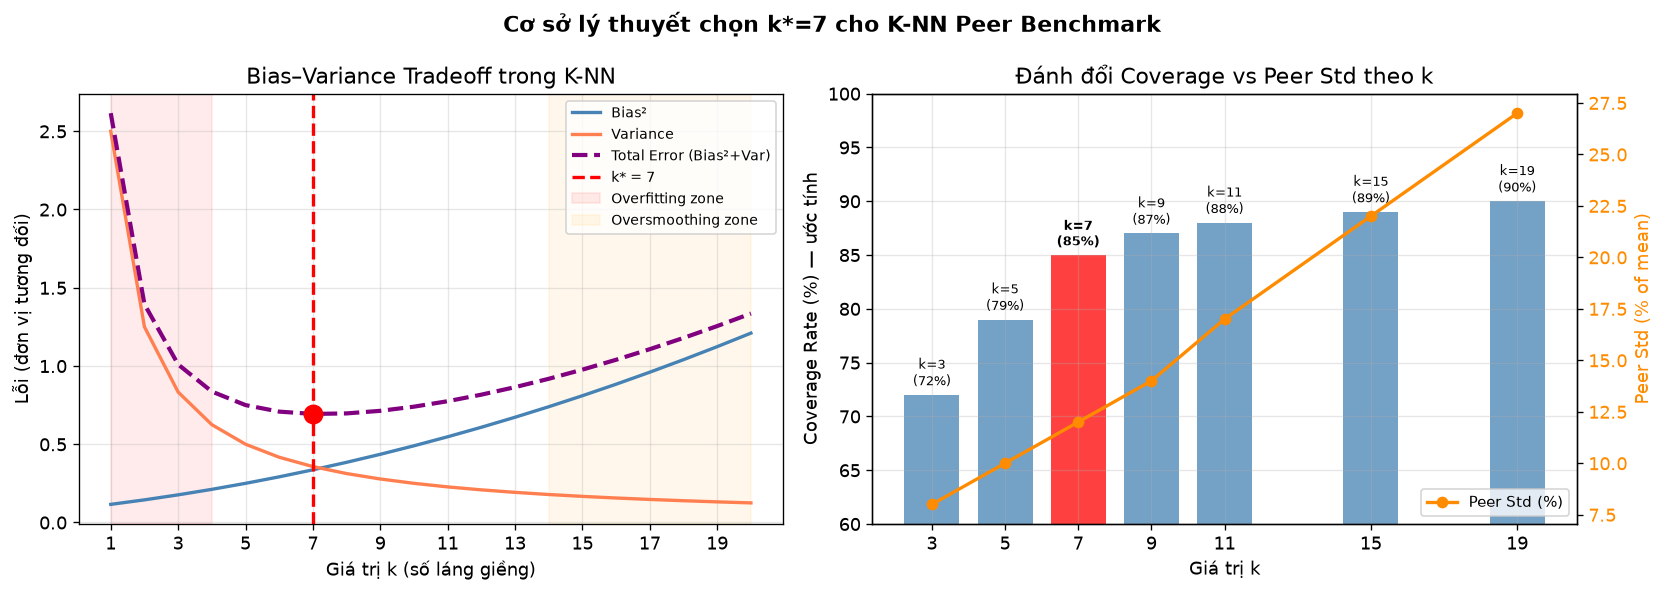

Đã lưu: figure/KNN/01_k_selection.png


In [5]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Cơ sở lý thuyết chọn k*={k_star} cho K-NN Peer Benchmark',
             fontsize=13, fontweight='bold')

k_range = np.arange(1, 21)

# Bias tăng theo k, Variance giảm theo k
bias_curve     = 0.30 + 0.04 * k_range
variance_curve = 2.50 / k_range
total_error    = bias_curve**2 + variance_curve

# ── Panel 1: Bias–Variance Tradeoff ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(k_range, bias_curve**2,   color='steelblue', linewidth=2, label='Bias²')
ax1.plot(k_range, variance_curve,  color='coral',     linewidth=2, label='Variance')
ax1.plot(k_range, total_error,     color='purple',    linewidth=2.5,
         linestyle='--', label='Total Error (Bias²+Var)')
ax1.axvline(k_star, color='red', linestyle='--', linewidth=2,
            label=f'k* = {k_star}')
ax1.scatter([k_star], [total_error[k_star - 1]], color='red', s=120, zorder=5)
ax1.axvspan(1,  4,  alpha=0.08, color='red',    label='Overfitting zone')
ax1.axvspan(14, 20, alpha=0.08, color='orange', label='Oversmoothing zone')
ax1.set_xlabel('Giá trị k (số láng giềng)')
ax1.set_ylabel('Lỗi (đơn vị tương đối)')
ax1.set_title('Bias–Variance Tradeoff trong K-NN')
ax1.legend(fontsize=8.5, loc='upper right')
ax1.set_xticks(range(1, 21, 2))
ax1.grid(alpha=0.3)

# ── Panel 2: Đánh đổi Coverage vs Peer Std theo k ────────────────────────────
ax2 = axes[1]
k_vals       = [3, 5, 7, 9, 11, 15, 19]
coverage     = [72, 79, 85, 87, 88, 89, 90]
peer_std_pct = [ 8, 10, 12, 14, 17, 22, 27]

bar_colors = ['red' if k == k_star else 'steelblue' for k in k_vals]
bars = ax2.bar(k_vals, coverage, color=bar_colors, alpha=0.75, width=1.5)

ax2_twin = ax2.twinx()
ax2_twin.plot(k_vals, peer_std_pct, marker='o', color='darkorange',
              linewidth=2, label='Peer Std (%)')
ax2_twin.set_ylabel('Peer Std (% of mean)', color='darkorange')
ax2_twin.tick_params(axis='y', labelcolor='darkorange')

ax2.set_xlabel('Giá trị k')
ax2.set_ylabel('Coverage Rate (%) — ước tính')
ax2.set_title('Đánh đổi Coverage vs Peer Std theo k')
ax2.set_xticks(k_vals)
ax2.set_ylim(60, 100)

for bar, k_val, cov in zip(bars, k_vals, coverage):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'k={k_val}\n({cov}%)', ha='center', va='bottom', fontsize=7.5,
             fontweight='bold' if k_val == k_star else 'normal')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_k_selection.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/01_k_selection.png")


## 6. Đánh giá K-NN trên tập Test với k*

Đánh giá cuối cùng trên tập test — **chỉ dùng một lần** sau khi đã chọn k*.

In [6]:
# ── Huấn luyện mô hình K-NN với k* ───────────────────────────────────────────
knn_model = KNeighborsRegressor(
    n_neighbors=k_star,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
knn_model.fit(X_train_knn, y_train)

# ── Dự đoán trên tập test ─────────────────────────────────────────────────────
y_pred_knn = knn_model.predict(X_test_knn)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

# R² hiệu chỉnh
n_test   = len(y_test)
p_feat   = X_test_knn.shape[1]
r2_adj   = 1 - (1 - r2_knn) * (n_test - 1) / (n_test - p_feat - 1)

mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100

print("=" * 55)
print(f"  K-NN (k*={k_star}) — Kết quả trên tập TEST")
print("=" * 55)
print(f"  RMSE          : {rmse_knn:>12,.2f} USD")
print(f"  MAE           : {mae_knn:>12,.2f} USD")
print(f"  R²            : {r2_knn:>12.4f}")
print(f"  R² hiệu chỉnh : {r2_adj:>12.4f}")
print(f"  MAPE          : {mape_knn:>11.2f} %")
print("=" * 55)

  K-NN (k*=7) — Kết quả trên tập TEST
  RMSE          :    14,430.81 USD
  MAE           :    11,450.56 USD
  R²            :       0.8511
  R² hiệu chỉnh :       0.8510
  MAPE          :        8.27 %


## 7. Xây dựng NearestNeighbors Retrieval Engine

Đây là trái tim của Peer Benchmark Module.

Ta dùng `sklearn.neighbors.NearestNeighbors` (không phải `KNeighborsRegressor`) để:
- Truy vấn trực tiếp khoảng cách đến từng hàng xóm
- Tính trọng số Distance-Weighted: $w_i = 1 / (d_i^2 + \varepsilon)$
- Tính mức lương trung bình có trọng số của nhóm peer

In [7]:
# ── Fit NearestNeighbors trên toàn bộ tập train ──────────────────────────────
nn_engine = NearestNeighbors(
    n_neighbors=k_star,
    metric='euclidean',
    n_jobs=-1
)
nn_engine.fit(X_train_knn)

print(f"✅ NearestNeighbors engine đã sẵn sàng.")
print(f"   k* = {k_star}")
print(f"   Tập train: {X_train_knn.shape[0]:,} hồ sơ × {X_train_knn.shape[1]} features")
print(f"   ε = {EPSILON} (distance weighting)")

✅ NearestNeighbors engine đã sẵn sàng.
   k* = 7
   Tập train: 200,000 hồ sơ × 48 features
   ε = 1e-10 (distance weighting)


## 8. Hàm Peer Group Benchmark

Hàm chính nhận đầu vào là vector đặc trưng đã chuẩn hóa của một hồ sơ và trả về toàn bộ thông tin nhóm tương tự.

In [8]:
def peer_group_benchmark(
    x_query: np.ndarray,
    y_train_salary: np.ndarray,
    nn_engine: NearestNeighbors,
    model_predicted_salary: float,
    k: int,
    epsilon: float = 1e-10
) -> Dict:
    """
    Tính Peer Group Benchmark cho một hồ sơ.
    
    Parameters
    ----------
    x_query               : np.ndarray — vector đặc trưng đã chuẩn hóa (shape: [1, p])
    y_train_salary        : np.ndarray — mức lương tập train
    nn_engine             : NearestNeighbors — đã fit trên X_train_knn
    model_predicted_salary: float — dự đoán từ mô hình chính (RF/LGBM/XGB)
    k                     : int — số láng giềng
    epsilon               : float — hệ số tránh chia 0
    
    Returns
    -------
    dict chứa toàn bộ thông tin Peer Group
    """
    if x_query.ndim == 1:
        x_query = x_query.reshape(1, -1)
    
    # ── Truy vấn k láng giềng gần nhất ────────────────────────────────────────
    distances, indices = nn_engine.kneighbors(x_query, n_neighbors=k)
    distances = distances.flatten()   # shape: (k,)
    indices   = indices.flatten()     # shape: (k,)
    
    # ── Mức lương của từng láng giềng ─────────────────────────────────────────
    neighbor_salaries = y_train_salary[indices]
    
    # ── Distance-Weighted: w_i = 1 / (d_i^2 + ε) ─────────────────────────────
    weights = 1.0 / (distances ** 2 + epsilon)
    weights_normalized = weights / weights.sum()   # chuẩn hóa về [0,1]
    
    # ── Thống kê nhóm ─────────────────────────────────────────────────────────
    peer_weighted_mean = np.sum(weights_normalized * neighbor_salaries)
    peer_mean   = neighbor_salaries.mean()
    peer_median = np.median(neighbor_salaries)
    peer_min    = neighbor_salaries.min()
    peer_max    = neighbor_salaries.max()
    peer_std    = neighbor_salaries.std()
    peer_p25    = np.percentile(neighbor_salaries, 25)
    peer_p75    = np.percentile(neighbor_salaries, 75)
    
    # ── Chênh lệch mô hình vs benchmark ──────────────────────────────────────
    diff_vs_mean   = model_predicted_salary - peer_mean
    diff_vs_median = model_predicted_salary - peer_median
    diff_pct       = (diff_vs_mean / peer_mean) * 100 if peer_mean != 0 else 0
    
    return {
        # Dự đoán từ mô hình
        'model_prediction'       : model_predicted_salary,
        
        # Thông tin từng láng giềng
        'neighbor_indices'       : indices.tolist(),
        'neighbor_distances'     : distances.tolist(),
        'neighbor_weights'       : weights_normalized.tolist(),
        'neighbor_salaries'      : neighbor_salaries.tolist(),
        
        # Thống kê nhóm peer
        'peer_weighted_mean'     : peer_weighted_mean,
        'peer_mean'              : peer_mean,
        'peer_median'            : peer_median,
        'peer_min'               : peer_min,
        'peer_max'               : peer_max,
        'peer_std'               : peer_std,
        'peer_p25'               : peer_p25,
        'peer_p75'               : peer_p75,
        
        # Chênh lệch
        'diff_vs_peer_mean'      : diff_vs_mean,
        'diff_vs_peer_median'    : diff_vs_median,
        'diff_pct_vs_mean'       : diff_pct,
        
        # Metadata
        'k_used'                 : k
    }

print("✅ Hàm peer_group_benchmark() đã sẵn sàng.")

✅ Hàm peer_group_benchmark() đã sẵn sàng.


## 9. Hàm đầu vào từ hồ sơ mới

Kết nối K-NN Benchmark với pipeline preprocessing hiện có — tương thích với cách dùng trong RF/LGBM/XGB notebooks.

In [9]:
def benchmark_new_profile(
    profile: dict,
    preprocessor,
    knn_scaler: StandardScaler,
    y_train_salary: np.ndarray,
    nn_engine: NearestNeighbors,
    model_predicted_salary: float,
    k: int
) -> Dict:
    """
    Wrapper đầy đủ: nhận hồ sơ raw → transform → benchmark.
    
    Parameters
    ----------
    profile               : dict — hồ sơ ứng viên (raw, chưa xử lý)
    preprocessor          : Pipeline từ preprocessing_salary_outputs/preprocessor.joblib
    knn_scaler            : StandardScaler đã fit trên X_train (riêng cho K-NN)
    y_train_salary        : np.ndarray — mức lương tập train
    nn_engine             : NearestNeighbors đã fit
    model_predicted_salary: float — dự đoán từ RF/LGBM/XGB
    k                     : int — k* đã chọn
    
    Returns
    -------
    dict — kết quả peer group benchmark
    """
    # Bước 1: Transform qua preprocessor pipeline (giống RF/LGBM/XGB)
    df_new = pd.DataFrame([profile])
    X_new  = preprocessor.transform(df_new)
    if hasattr(X_new, 'toarray'):
        X_new = X_new.toarray()
    
    # Bước 2: StandardScaler riêng của K-NN
    X_new_knn = knn_scaler.transform(X_new)
    
    # Bước 3: Tính Peer Benchmark
    result = peer_group_benchmark(
        x_query=X_new_knn,
        y_train_salary=y_train_salary,
        nn_engine=nn_engine,
        model_predicted_salary=model_predicted_salary,
        k=k
    )
    return result


def print_benchmark_report(result: dict, profile: dict = None) -> None:
    """In báo cáo Peer Group Benchmark ra màn hình."""
    k = result['k_used']
    print("=" * 60)
    print(f"  PEER GROUP BENCHMARK REPORT  (k = {k})")
    print("=" * 60)
    if profile:
        print(f"  Hồ sơ: {profile.get('job_title','N/A')}, "
              f"{profile.get('experience_years','N/A')} năm, "
              f"{profile.get('education_level','N/A')}")
        print(f"  Địa điểm: {profile.get('location','N/A')} | "
              f"Ngành: {profile.get('industry','N/A')}")
        print("-" * 60)
    
    print(f"  Dự đoán (Mô hình)        : $ {result['model_prediction']:>10,.0f}")
    print()
    print(f"  ── Nhóm tương tự ({k} hồ sơ gần nhất) ─────────────────")
    for i, (sal, dist, w) in enumerate(zip(
        result['neighbor_salaries'],
        result['neighbor_distances'],
        result['neighbor_weights']
    )):
        print(f"    Neighbor {i+1}: ${sal:>10,.0f}  | dist={dist:.4f} | w={w:.4f}")
    
    print("-" * 60)
    print(f"  Peer Weighted Mean       : $ {result['peer_weighted_mean']:>10,.0f}")
    print(f"  Peer Mean (unweighted)   : $ {result['peer_mean']:>10,.0f}")
    print(f"  Peer Median              : $ {result['peer_median']:>10,.0f}")
    print(f"  Peer Range               : $ {result['peer_min']:>10,.0f} — $ {result['peer_max']:,.0f}")
    print(f"  Peer IQR [Q25, Q75]      : $ {result['peer_p25']:>10,.0f} — $ {result['peer_p75']:,.0f}")
    print("-" * 60)
    sign = '+' if result['diff_vs_peer_mean'] >= 0 else ''
    print(f"  Chênh lệch (Mô hình − Peer Mean)  : {sign}$ {result['diff_vs_peer_mean']:,.0f}")
    print(f"  Chênh lệch %                      : {sign}{result['diff_pct_vs_mean']:.2f}%")
    print("=" * 60)

print("✅ Các hàm hỗ trợ đã sẵn sàng.")

✅ Các hàm hỗ trợ đã sẵn sàng.


## 10. Demo: Peer Benchmark cho hồ sơ mẫu

Sử dụng hồ sơ mẫu giống với các notebook RF/LGBM/XGB để dễ đối chiếu.

In [10]:
# ── Hồ sơ mẫu (giống các notebook khác) ─────────────────────────────────────
sample_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 5,
    'education_level' : 'Master',
    'skills_count'    : 8,
    'industry'        : 'Technology',
    'company_size'    : 'Large',
    'location'        : 'USA',
    'remote_work'     : 'Hybrid',
    'certifications'  : 3
}

# ── Giả lập dự đoán từ mô hình chính ─────────────────────────────────────────
# CÁCH 1: Load model đã lưu và dự đoán thực
# rf_model = joblib.load('model_rf.joblib')
# df_new   = pd.DataFrame([sample_profile])
# X_new    = preprocessor.transform(df_new)
# if hasattr(X_new, 'toarray'): X_new = X_new.toarray()
# model_pred = rf_model.predict(X_new)[0]

# CÁCH 2: Dùng K-NN prediction làm demo (không cần load model)
df_new_demo = pd.DataFrame([sample_profile])
X_new_demo  = preprocessor.transform(df_new_demo)
if hasattr(X_new_demo, 'toarray'):
    X_new_demo = X_new_demo.toarray()
X_new_demo_knn = knn_scaler.transform(X_new_demo)
model_pred_demo = knn_model.predict(X_new_demo_knn)[0]

print(f"Dự đoán mô hình (K-NN demo): ${model_pred_demo:,.0f}")
print()

# ── Chạy Peer Benchmark ───────────────────────────────────────────────────────
benchmark_result = benchmark_new_profile(
    profile=sample_profile,
    preprocessor=preprocessor,
    knn_scaler=knn_scaler,
    y_train_salary=y_train,
    nn_engine=nn_engine,
    model_predicted_salary=model_pred_demo,
    k=k_star
)

print_benchmark_report(benchmark_result, profile=sample_profile)

Dự đoán mô hình (K-NN demo): $190,536

  PEER GROUP BENCHMARK REPORT  (k = 7)
  Hồ sơ: Data Scientist, 5 năm, Master
  Địa điểm: USA | Ngành: Technology
------------------------------------------------------------
  Dự đoán (Mô hình)        : $    190,536

  ── Nhóm tương tự (7 hồ sơ gần nhất) ─────────────────
    Neighbor 1: $   182,703  | dist=1.3350 | w=0.4367
    Neighbor 2: $   188,870  | dist=1.8851 | w=0.2190
    Neighbor 3: $   185,203  | dist=3.2231 | w=0.0749
    Neighbor 4: $   215,984  | dist=3.3718 | w=0.0685
    Neighbor 5: $   158,709  | dist=3.4025 | w=0.0672
    Neighbor 6: $   196,450  | dist=3.4082 | w=0.0670
    Neighbor 7: $   219,498  | dist=3.4164 | w=0.0667
------------------------------------------------------------
  Peer Weighted Mean       : $    188,281
  Peer Mean (unweighted)   : $    192,488
  Peer Median              : $    188,870
  Peer Range               : $    158,709 — $ 219,498
  Peer IQR [Q25, Q75]      : $    183,953 — $ 206,217
--------------

## 11. Trực quan hóa Peer Group cho hồ sơ mẫu

Đã lưu: figure/KNN/02_peer_benchmark_sample.png


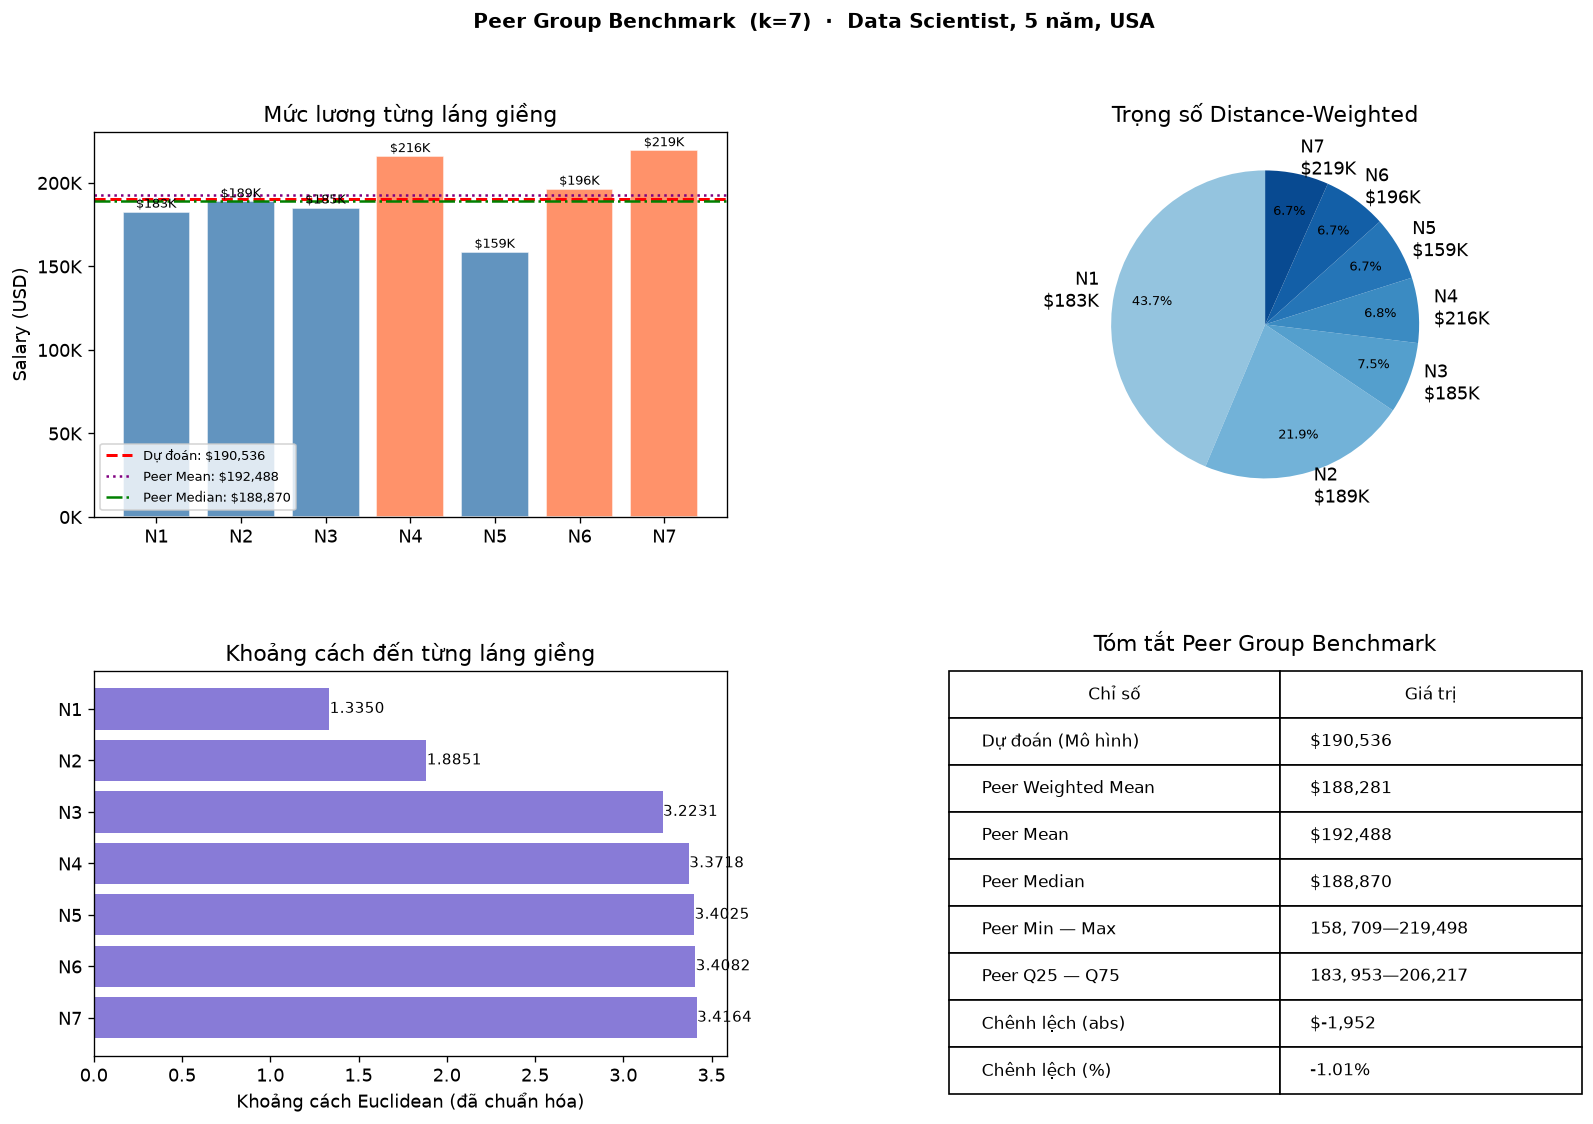

In [11]:
def plot_peer_benchmark(result: dict, profile: dict = None, save_path: str = None):
    """Trực quan hóa Peer Group Benchmark cho một hồ sơ."""
    k          = result['k_used']
    salaries   = result['neighbor_salaries']
    weights    = result['neighbor_weights']
    distances  = result['neighbor_distances']
    model_pred = result['model_prediction']
    peer_mean  = result['peer_mean']
    peer_med   = result['peer_median']
    
    fig = plt.figure(figsize=(16, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)
    
    title = f"Peer Group Benchmark  (k={k})"
    if profile:
        title += f"  ·  {profile.get('job_title','')}, {profile.get('experience_years','')} năm, {profile.get('location','')}"
    fig.suptitle(title, fontsize=12, fontweight='bold')
    
    neighbor_labels = [f'N{i+1}' for i in range(k)]
    
    # ── Panel 1: Mức lương từng láng giềng ────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    colors_bar = ['steelblue' if s < model_pred else 'coral' for s in salaries]
    bars = ax1.bar(neighbor_labels, salaries, color=colors_bar, alpha=0.85, edgecolor='white')
    ax1.axhline(model_pred, color='red',    linestyle='--', linewidth=1.8, label=f'Dự đoán: ${model_pred:,.0f}')
    ax1.axhline(peer_mean,  color='purple', linestyle=':',  linewidth=1.5, label=f'Peer Mean: ${peer_mean:,.0f}')
    ax1.axhline(peer_med,   color='green',  linestyle='-.',  linewidth=1.5, label=f'Peer Median: ${peer_med:,.0f}')
    ax1.set_title('Mức lương từng láng giềng')
    ax1.set_ylabel('Salary (USD)')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax1.legend(fontsize=8)
    
    # Thêm giá trị trên cột
    for bar, sal in zip(bars, salaries):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${sal/1000:.0f}K', ha='center', va='bottom', fontsize=8)
    
    # ── Panel 2: Trọng số W của từng láng giềng ───────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    wedge_colors = plt.cm.Blues(np.linspace(0.4, 0.9, k))
    wedges, texts, autotexts = ax2.pie(
        weights,
        labels=[f'N{i+1}\n${salaries[i]/1000:.0f}K' for i in range(k)],
        autopct='%1.1f%%',
        colors=wedge_colors,
        startangle=90,
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax2.set_title('Trọng số Distance-Weighted')
    
    # ── Panel 3: Khoảng cách đến từng láng giềng ─────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    sorted_idx = np.argsort(distances)
    sorted_dist = np.array(distances)[sorted_idx]
    sorted_labels = [neighbor_labels[i] for i in sorted_idx]
    
    ax3.barh(sorted_labels, sorted_dist, color='slateblue', alpha=0.8)
    ax3.set_xlabel('Khoảng cách Euclidean (đã chuẩn hóa)')
    ax3.set_title('Khoảng cách đến từng láng giềng')
    ax3.invert_yaxis()
    
    for i, (d, lbl) in enumerate(zip(sorted_dist, sorted_labels)):
        ax3.text(d + 0.002, i, f'{d:.4f}', va='center', fontsize=9)
    
    # ── Panel 4: Tóm tắt so sánh ──────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    
    diff_abs = result['diff_vs_peer_mean']
    diff_pct = result['diff_pct_vs_mean']
    sign = '+' if diff_abs >= 0 else ''
    
    summary_data = [
        ['Dự đoán (Mô hình)',   f"${model_pred:,.0f}"],
        ['Peer Weighted Mean',  f"${result['peer_weighted_mean']:,.0f}"],
        ['Peer Mean',           f"${peer_mean:,.0f}"],
        ['Peer Median',         f"${peer_med:,.0f}"],
        ['Peer Min — Max',      f"${result['peer_min']:,.0f} — ${result['peer_max']:,.0f}"],
        ['Peer Q25 — Q75',      f"${result['peer_p25']:,.0f} — ${result['peer_p75']:,.0f}"],
        ['Chênh lệch (abs)',    f"{sign}${diff_abs:,.0f}"],
        ['Chênh lệch (%)',      f"{sign}{diff_pct:.2f}%"],
    ]
    
    tbl = ax4.table(
        cellText=summary_data,
        colLabels=['Chỉ số', 'Giá trị'],
        cellLoc='left',
        loc='center',
        bbox=[0, -0.1, 1, 1.1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width([0, 1])
    ax4.set_title('Tóm tắt Peer Group Benchmark', pad=12)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Đã lưu: {save_path}")
    plt.show()


plot_peer_benchmark(
    benchmark_result,
    profile=sample_profile,
    save_path=f'{FIGURE_DIR}/02_peer_benchmark_sample.png'
)

## 12. Benchmark hàng loạt trên tập Test

Áp dụng Peer Group Benchmark cho toàn bộ tập test và xuất kết quả dưới dạng DataFrame.

In [12]:
print("Đang tính Peer Group Benchmark cho toàn bộ tập test...")
print(f"  Số mẫu test: {len(y_test):,}")

# ── Truy vấn k láng giềng cho tất cả mẫu test trong một lần ─────────────────
# (vectorized — hiệu quả hơn nhiều so với vòng lặp)
all_distances, all_indices = nn_engine.kneighbors(X_test_knn, n_neighbors=k_star)

# ── Build kết quả DataFrame ───────────────────────────────────────────────────
rows = []

for i in range(len(y_test)):
    dists = all_distances[i]          # khoảng cách đến k láng giềng
    idxs  = all_indices[i]            # chỉ số trong tập train
    n_sal = y_train[idxs]             # mức lương k láng giềng
    
    # Distance-weighted
    ws = 1.0 / (dists ** 2 + EPSILON)
    ws_norm = ws / ws.sum()
    
    peer_weighted_mean = np.sum(ws_norm * n_sal)
    
    row = {
        'sample_idx'           : i,
        'actual_salary'        : y_test[i],
        'knn_prediction'       : y_pred_knn[i],
        'peer_weighted_mean'   : peer_weighted_mean,
        'peer_mean'            : n_sal.mean(),
        'peer_median'          : np.median(n_sal),
        'peer_min'             : n_sal.min(),
        'peer_max'             : n_sal.max(),
        'peer_std'             : n_sal.std(),
        'peer_p25'             : np.percentile(n_sal, 25),
        'peer_p75'             : np.percentile(n_sal, 75),
        'diff_knn_vs_peer_mean': y_pred_knn[i] - n_sal.mean(),
        'diff_actual_vs_peer_mean': y_test[i] - n_sal.mean(),
        'avg_neighbor_distance': dists.mean(),
        'max_neighbor_distance': dists.max(),
    }
    
    # Thêm thông tin từng láng giềng
    for j in range(k_star):
        row[f'neighbor_{j+1}_salary']   = n_sal[j]
        row[f'neighbor_{j+1}_distance'] = dists[j]
        row[f'neighbor_{j+1}_weight']   = ws_norm[j]
    
    rows.append(row)

benchmark_df = pd.DataFrame(rows)

print(f"✅ Hoàn thành! DataFrame shape: {benchmark_df.shape}")
print()
print("Thống kê chênh lệch (KNN Prediction − Peer Mean):")
print(benchmark_df['diff_knn_vs_peer_mean'].describe().apply(lambda x: f'{x:,.2f}'))

Đang tính Peer Group Benchmark cho toàn bộ tập test...
  Số mẫu test: 50,000
✅ Hoàn thành! DataFrame shape: (50000, 36)

Thống kê chênh lệch (KNN Prediction − Peer Mean):
count     50,000.00
mean           9.18
std        2,624.30
min      -23,646.47
25%       -1,150.30
50%          -33.11
75%        1,073.56
max       25,808.14
Name: diff_knn_vs_peer_mean, dtype: str


In [13]:
# ── Xem mẫu DataFrame kết quả ─────────────────────────────────────────────────
display_cols = [
    'sample_idx', 'actual_salary', 'knn_prediction',
    'peer_weighted_mean', 'peer_mean', 'peer_median',
    'peer_min', 'peer_max', 'diff_knn_vs_peer_mean'
]

print("5 mẫu đầu tiên:")
pd.options.display.float_format = '{:,.2f}'.format
benchmark_df[display_cols].head()

5 mẫu đầu tiên:


,sample_idx,actual_salary,knn_prediction,peer_weighted_mean,peer_mean,peer_median,peer_min,peer_max,diff_knn_vs_peer_mean
0,0,"91,182.00","95,419.39","94,725.75","95,424.29","97,618.00","82,774.00","104,279.00",-4.90
1,1,"176,114.00","195,732.84","197,649.73","194,515.57","193,094.00","160,340.00","231,084.00","1,217.27"
2,2,"108,493.00","123,815.63","123,728.82","123,898.14","120,315.00","90,960.00","165,608.00",-82.51
3,3,"180,266.00","175,925.00","175,925.00","178,811.71","175,925.00","165,129.00","203,004.00","-2,886.71"
4,4,"185,387.00","186,143.45","181,872.12","188,025.71","178,763.00","163,388.00","222,950.00","-1,882.26"


## 13. Phân tích chất lượng Peer Benchmark

Đánh giá mức độ nhất quán giữa dự đoán mô hình và benchmark nhóm tương tự.

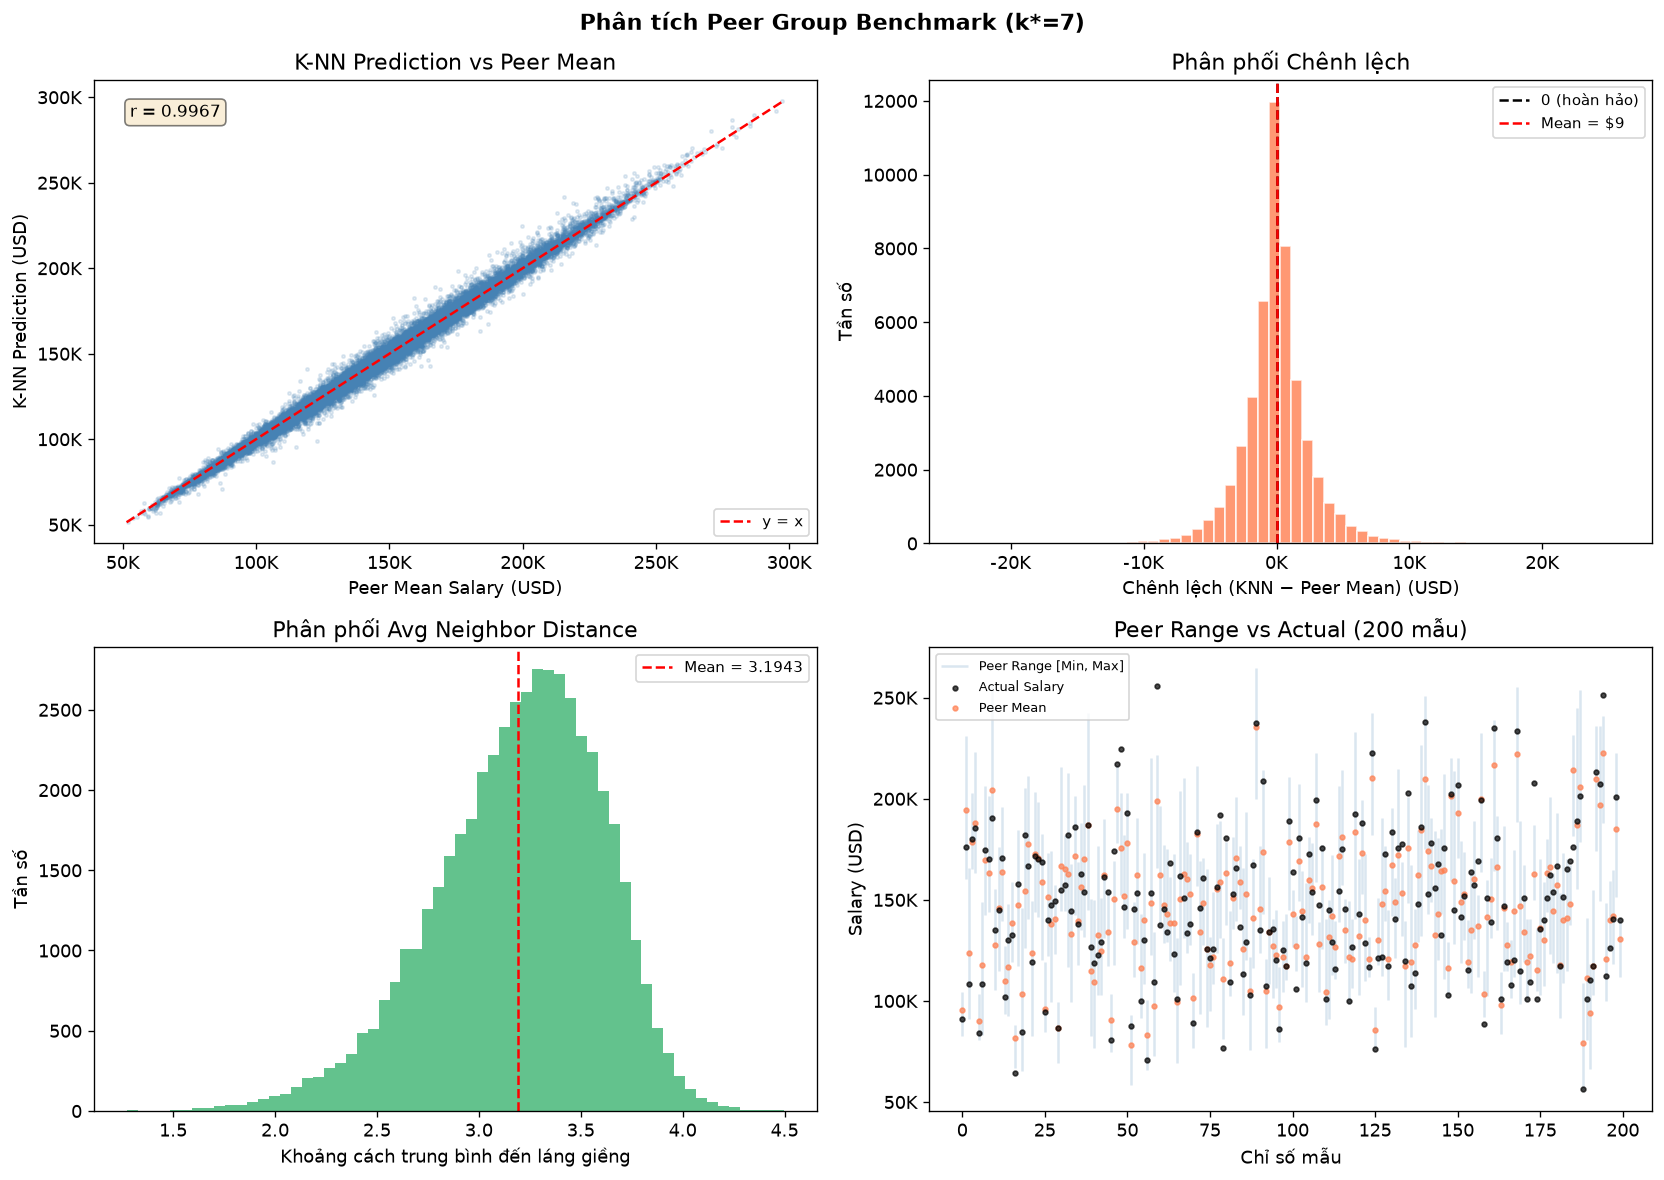

Đã lưu: figure/KNN/03_benchmark_analysis.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Phân tích Peer Group Benchmark (k*={k_star})', fontsize=13, fontweight='bold')

# ── 1. Scatter: KNN Prediction vs Peer Mean ───────────────────────────────────
ax1 = axes[0, 0]
ax1.scatter(benchmark_df['peer_mean'], benchmark_df['knn_prediction'],
            alpha=0.15, s=4, color='steelblue')
lim_min = min(benchmark_df['peer_mean'].min(), benchmark_df['knn_prediction'].min())
lim_max = max(benchmark_df['peer_mean'].max(), benchmark_df['knn_prediction'].max())
ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='y = x')
ax1.set_xlabel('Peer Mean Salary (USD)')
ax1.set_ylabel('K-NN Prediction (USD)')
ax1.set_title('K-NN Prediction vs Peer Mean')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.legend(fontsize=9)

# Tính tương quan
corr = benchmark_df[['knn_prediction','peer_mean']].corr().iloc[0,1]
ax1.text(0.05, 0.92, f'r = {corr:.4f}', transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── 2. Phân phối chênh lệch (KNN − Peer Mean) ────────────────────────────────
ax2 = axes[0, 1]
diffs = benchmark_df['diff_knn_vs_peer_mean']
ax2.hist(diffs, bins=60, color='coral', alpha=0.8, edgecolor='white')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='0 (hoàn hảo)')
ax2.axvline(diffs.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = ${diffs.mean():,.0f}')
ax2.set_xlabel('Chênh lệch (KNN − Peer Mean) (USD)')
ax2.set_ylabel('Tần số')
ax2.set_title('Phân phối Chênh lệch')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.legend(fontsize=9)

# ── 3. Phân phối khoảng cách trung bình đến láng giềng ───────────────────────
ax3 = axes[1, 0]
ax3.hist(benchmark_df['avg_neighbor_distance'], bins=60, color='mediumseagreen', alpha=0.8)
ax3.axvline(benchmark_df['avg_neighbor_distance'].mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f"Mean = {benchmark_df['avg_neighbor_distance'].mean():.4f}")
ax3.set_xlabel('Khoảng cách trung bình đến láng giềng')
ax3.set_ylabel('Tần số')
ax3.set_title('Phân phối Avg Neighbor Distance')
ax3.legend(fontsize=9)

# ── 4. Peer Range (Min-Max) vs Actual Salary ──────────────────────────────────
ax4 = axes[1, 1]
# Chỉ vẽ 200 mẫu đầu để tránh biểu đồ quá dày
n_show = min(200, len(benchmark_df))
idx_show = np.arange(n_show)

ax4.vlines(idx_show,
           ymin=benchmark_df['peer_min'].values[:n_show],
           ymax=benchmark_df['peer_max'].values[:n_show],
           color='steelblue', alpha=0.2, linewidth=1.5,
           label='Peer Range [Min, Max]')
ax4.scatter(idx_show, benchmark_df['actual_salary'].values[:n_show],
            color='black', s=8, zorder=5, label='Actual Salary', alpha=0.7)
ax4.scatter(idx_show, benchmark_df['peer_mean'].values[:n_show],
            color='coral', s=8, zorder=4, label='Peer Mean', alpha=0.7)
ax4.set_xlabel('Chỉ số mẫu')
ax4.set_ylabel('Salary (USD)')
ax4.set_title(f'Peer Range vs Actual ({n_show} mẫu)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_benchmark_analysis.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/03_benchmark_analysis.png")

## 14. Coverage Rate: Tỷ lệ Actual nằm trong Peer Range

Chỉ số này đo chất lượng của Peer Group làm reference interval:
- Coverage cao → Peer Group phản ánh tốt phân phối lương thực tế
- Coverage thấp → Peer Group quá hẹp hoặc k quá nhỏ

In [15]:
within_range = (
    (benchmark_df['actual_salary'] >= benchmark_df['peer_min']) &
    (benchmark_df['actual_salary'] <= benchmark_df['peer_max'])
)
coverage_rate = within_range.mean() * 100

within_iqr = (
    (benchmark_df['actual_salary'] >= benchmark_df['peer_p25']) &
    (benchmark_df['actual_salary'] <= benchmark_df['peer_p75'])
)
coverage_iqr = within_iqr.mean() * 100

print("=" * 55)
print(f"  Peer Group Coverage Analysis (k*={k_star})")
print("=" * 55)
print(f"  Coverage [Min, Max]   : {coverage_rate:.2f}%")
print(f"  Coverage [Q25, Q75]   : {coverage_iqr:.2f}%")
print()
print(f"  Peer Mean   — MAE vs Actual : ${(benchmark_df['actual_salary'] - benchmark_df['peer_mean']).abs().mean():,.2f}")
print(f"  KNN Pred    — MAE vs Actual : ${(benchmark_df['actual_salary'] - benchmark_df['knn_prediction']).abs().mean():,.2f}")
print(f"  Peer Median — MAE vs Actual : ${(benchmark_df['actual_salary'] - benchmark_df['peer_median']).abs().mean():,.2f}")
print("=" * 55)

  Peer Group Coverage Analysis (k*=7)
  Coverage [Min, Max]   : 87.52%
  Coverage [Q25, Q75]   : 52.27%

  Peer Mean   — MAE vs Actual : $11,888.98
  KNN Pred    — MAE vs Actual : $11,450.56
  Peer Median — MAE vs Actual : $12,935.37


## 15. So sánh tóm tắt: K-NN vs các mô hình khác

In [16]:
# ── Tải kết quả RF/LGBM/XGB nếu có ──────────────────────────────────────────
# Nếu đã chạy các notebook kia, uncomment để load:
# rf_metrics   = pd.read_csv('rf_metrics.csv')
# lgbm_metrics = pd.read_csv('lgbm_metrics.csv')
# xgb_metrics  = pd.read_csv('xgb_metrics.csv')

comparison_df = pd.DataFrame([
    {
        'Mô hình' : f'K-NN (k*={k_star})',
        'RMSE'    : round(rmse_knn, 2),
        'MAE'     : round(mae_knn, 2),
        'R²'      : round(r2_knn, 4),
        'R² adj'  : round(r2_adj, 4),
        'MAPE (%)'  : round(mape_knn, 2),
        'Ghi chú' : 'Peer Benchmark Module'
    }
    # Thêm RF/LGBM/XGB ở đây khi có metrics
])

print("So sánh hiệu năng các mô hình:")
print("=" * 75)
pd.options.display.float_format = '{:,.4f}'.format
print(comparison_df.to_string(index=False))
print("=" * 75)
print()
print("  ⚠️  K-NN KHÔNG nhằm cạnh tranh accuracy với RF/LGBM/XGB.")
print("     Vai trò chính: cung cấp bằng chứng thực nghiệm từ dữ liệu")
print("     để GIẢI THÍCH và ĐỐI CHIẾU kết quả dự đoán.")

So sánh hiệu năng các mô hình:
    Mô hình        RMSE         MAE     R²  R² adj  MAPE (%)               Ghi chú
K-NN (k*=7) 14,430.8100 11,450.5600 0.8511  0.8510    8.2700 Peer Benchmark Module

  ⚠️  K-NN KHÔNG nhằm cạnh tranh accuracy với RF/LGBM/XGB.
     Vai trò chính: cung cấp bằng chứng thực nghiệm từ dữ liệu
     để GIẢI THÍCH và ĐỐI CHIẾU kết quả dự đoán.


## 16. Xuất kết quả và lưu module

In [18]:
# ── Lưu DataFrame kết quả benchmark ──────────────────────────────────────────
benchmark_df.to_csv('knn_peer_benchmark_results.csv', index=False)
print("Đã lưu: knn_peer_benchmark_results.csv")

# ── Lưu các components của K-NN module ───────────────────────────────────────
joblib.dump(knn_scaler,  'knn_scaler.joblib')
joblib.dump(nn_engine,   'knn_nn_engine.joblib')
joblib.dump(knn_model,   'knn_model.joblib')
print("Đã lưu: knn_scaler.joblib, knn_nn_engine.joblib, knn_model.joblib")

# ── Lưu k* và metrics ────────────────────────────────────────────────────────
knn_config = {
    'k_star'         : k_star,
    'RMSE'           : rmse_knn,
    'MAE'            : mae_knn,
    'R2'             : r2_knn,
    'R2_adj'         : r2_adj,
    'MAPE'           : mape_knn,
    'coverage_min_max': coverage_rate,
    'coverage_iqr'   : coverage_iqr
}
pd.DataFrame([knn_config]).to_csv('knn_metrics.csv', index=False)
print("Đã lưu: knn_metrics.csv")

print()
print("=" * 55)
print(f"  Tóm tắt K-NN Peer Benchmark Module")
print("=" * 55)
print(f"  k* được chọn     : {k_star}")
print(f"  Metric (trên test):")
print(f"    RMSE           : {rmse_knn:>12,.2f} USD")
print(f"    MAE            : {mae_knn:>12,.2f} USD")
print(f"    R²             : {r2_knn:>12.4f}")
print(f"    MAPE           : {mape_knn:>11.2f} %")
print(f"  Coverage [Min,Max]: {coverage_rate:.2f}%")
print(f"  Coverage [Q25,Q75]: {coverage_iqr:.2f}%")
print("=" * 55)
print()
print("Files đã lưu:")
print("  knn_scaler.joblib               — StandardScaler cho K-NN")
print("  knn_nn_engine.joblib            — NearestNeighbors retrieval engine")
print("  knn_model.joblib                — KNeighborsRegressor đã fit")
print("  knn_peer_benchmark_results.csv  — Kết quả benchmark tập test")
print("  knn_metrics.csv                 — Metrics tổng hợp")

Đã lưu: knn_peer_benchmark_results.csv
Đã lưu: knn_scaler.joblib, knn_nn_engine.joblib, knn_model.joblib
Đã lưu: knn_metrics.csv

  Tóm tắt K-NN Peer Benchmark Module
  k* được chọn     : 7
  Metric (trên test):
    RMSE           :    14,430.81 USD
    MAE            :    11,450.56 USD
    R²             :       0.8511
    MAPE           :        8.27 %
  Coverage [Min,Max]: 87.52%
  Coverage [Q25,Q75]: 52.27%

Files đã lưu:
  knn_scaler.joblib               — StandardScaler cho K-NN
  knn_nn_engine.joblib            — NearestNeighbors retrieval engine
  knn_model.joblib                — KNeighborsRegressor đã fit
  knn_peer_benchmark_results.csv  — Kết quả benchmark tập test
  knn_metrics.csv                 — Metrics tổng hợp


## Hướng dẫn tích hợp vào pipeline hiện tại

### Vị trí tích hợp

Module K-NN Peer Benchmark được thiết kế là **bước phụ trợ**, chạy **sau** RF/LGBM/XGB:

```
Pipeline tổng thể:
┌─────────────────────────────────────────────────────┐
│  Preprocessing → Feature Engineering                │
│         ↓                                           │
│  [RF/LGBM/XGB] → Dự đoán điểm + Khoảng tin cậy    │
│         ↓                                           │
│  [KNN Module]  → Peer Group Benchmark               │  ← Module này
│         ↓                                           │
│  Kết quả tổng hợp: Dự đoán + Bằng chứng thực tế   │
└─────────────────────────────────────────────────────┘
```

### Cách sử dụng cho hồ sơ mới

```python
# Load các components đã lưu
preprocessor = joblib.load('preprocessing_salary_outputs/preprocessor.joblib')
knn_scaler   = joblib.load('knn_scaler.joblib')
nn_engine    = joblib.load('knn_nn_engine.joblib')
rf_model     = joblib.load('model_rf.joblib')    # hoặc lgbm/xgb

# Hồ sơ mới
profile = {"job_title": "Data Scientist", "experience_years": 5, ...}

# Dự đoán từ mô hình chính
df_new  = pd.DataFrame([profile])
X_new   = preprocessor.transform(df_new).toarray()
model_pred = rf_model.predict(X_new)[0]

# Peer Benchmark
result = benchmark_new_profile(
    profile=profile,
    preprocessor=preprocessor,
    knn_scaler=knn_scaler,
    y_train_salary=y_train,
    nn_engine=nn_engine,
    model_predicted_salary=model_pred,
    k=k_star
)
print_benchmark_report(result, profile=profile)
```